# 🛒 E-Commerce Business Intelligence & Operations Analysis
### *End-to-End Data Engineering and Insights Pipeline*

---

## 📌 Project Overview
This notebook demonstrates a comprehensive analytical workflow focused on a large-scale Brazilian e-commerce dataset. The goal is to move beyond simple visualization and into **operational intelligence**—identifying where revenue is lost, how customers pay, and which regions drive growth.

By merging **9 relational tables**, this project reconstructs the entire order lifecycle to answer critical business questions regarding logistics, payment behavior, and product performance.

---

## 🛠️ The Technical Roadmap
The analysis is structured into six logical phases:

1.  **Data Architecture & Wrangling:** Loading 9 relational tables, handling Portuguese-to-English translations, and performing strategic data cleaning (dropping redundant geospatial and sparse text data).
2.  **Customer Geospatial Analysis:** Mapping the concentration of the customer base across Brazilian states.
3.  **Order Lifecycle & Revenue Logic:** Engineering the `is_revenue` feature to distinguish between successful transactions and system-level "uncompleted" orders.
4.  **Product Analytics:** Ranking categories by both purchase frequency and total revenue contribution.
5.  **Financial Behavior:** Investigating the relationship between order value, payment methods (Credit Card, Boleto, Voucher), and installment preferences.
6.  **Sentiment Overview:** Quantifying customer satisfaction through review score distributions.

---

## 📊 Key Business Questions Addressed
*   **Market Dominance:** Which states represent the "Engine" of the platform?
*   **Friction Points:** What percentage of orders fail to reach "Delivered" status and why?
*   **Payment Psychology:** Does a higher `item_total` directly correlate with a higher number of installments?
*   **Category Health:** Which product categories are "High Volume" vs. "High Value"?

---

## 📦 Environment Setup
*   **Language:** Python 3.x
*   **Libraries:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `os`

---

### 💡 Implementation Note
> *This notebook utilizes a modular approach. Custom utility functions are used for repetitive tasks like column dropping and data merging to ensure the code remains DRY (Don't Repeat Yourself) and maintainable.*

---

### Data Preparation Steps:
- Imported core libraries: pandas, numpy, and os for data manipulation and environment handling


In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

- Loaded datasets dynamically using OS-based file paths to ensure reproducibility


In [2]:
path=r'C:\Users\Margaret Sasha\Downloads\OLIST' #folder with the dataset
os.chdir(path)# moves folder to path recognised by python

#load the datasets
dataframes={}
for file in os.listdir():
    full_path=os.path.join(path,file)
    df=pd.read_csv(full_path)
    dataframes[file[:-4]]=df

customers=dataframes['olist_customers_dataset']
geolocation=dataframes['olist_geolocation_dataset']
orders=dataframes['olist_orders_dataset']
order_items=dataframes['olist_order_items_dataset']
payment=dataframes['olist_order_payments_dataset']
reviews=dataframes['olist_order_reviews_dataset']
products=dataframes['olist_products_dataset']
sellers=dataframes['olist_sellers_dataset']
translation=dataframes['product_category_name_translation']

- Conducted schema validation across all tables

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info() #no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [5]:
geolocation.head(10) #will drop this later as most of the data except for the longitude and the lattitude is in the subsequent files

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
5,1012,-23.547762,-46.635361,são paulo,SP
6,1047,-23.546273,-46.641225,sao paulo,SP
7,1013,-23.546923,-46.634264,sao paulo,SP
8,1029,-23.543769,-46.634278,sao paulo,SP
9,1011,-23.547640,-46.636032,sao paulo,SP


In [6]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [9]:
order_items.head()# will later on ad an item_total metric to help calculate the total revenue per order

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [10]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [11]:
payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [12]:
payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [13]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [14]:
reviews.info()#the columns w missing values review_comment_title and review_comment_message could be ommited as they are not that important

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [15]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [16]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [17]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [18]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [19]:
translation.head() # will be used to later replace the product category names from portuguese to english

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Data Cleaning & Transformation:
- Dropped the geolocation dataset, as its non-coordinate attributes were redundant and available in other tables



In [20]:
del geolocation

- Built reusable utility functions to streamline column-level cleaning operations
- Removed `review_comment_title` and `review_comment_message` due to high null rates and low analytical relevance


In [21]:
def column_drop(df,col_name):
    return df.drop(columns=col_name,inplace=True)
column_drop(reviews,'review_comment_title')
column_drop(reviews,'review_comment_message')

reviews.head()

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01 00:00:00,2018-03-02 10:26:53


- Standardized product category names by mapping Portuguese labels to English using the translation table
- Converted relevant columns (e.g., photo quantity) to appropriate data types for consistency


In [22]:
#mapping translation
translation_dict=dict(zip(translation['product_category_name'],translation['product_category_name_english']))
products['product_category_name_en']=products['product_category_name'].map(translation_dict)

#convert to apporopriate dtype
products['product_photos_qty'] = products['product_photos_qty'].astype('float')
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_en
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


### Feature Engineering:
- Created an `item_total` metric within the order items dataset to represent transactional value at the item level

At this stage, the data was standardized, cleaned, and structured for downstream analysis.

In [23]:
#create item_total columns in order_items
order_items['item_total']=order_items['price']+order_items['freight_value']
#group by order_id
order_total=order_items.groupby('order_id').agg(total_order_value= ('item_total','sum'),total_items=('order_item_id','count')).reset_index()
order_total.head()

,order_id,total_order_value,total_items
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1


## Order & Revenue Analysis

This section focuses on understanding the lifecycle of orders, revenue generation, and operational performance.

### Data Integration:
- Merged order items with product data to enrich transactional records and created a full_data table for further analysis on this section. 
- Built a unified dataset by combining customers, orders, and order items 


In [24]:
#merge the datasets product and order_item so as to analyse the product categories that brought the most revenue
merged_df = pd.merge(order_items, products[['product_id', 'product_category_name_en']], on='product_id', how='left')
merged_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_total,product_category_name_en
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,garden_tools


In [25]:
merged_df.shape


(112650, 9)

In [26]:
merged_df.isnull().sum()


order_id                       0
order_item_id                  0
product_id                     0
seller_id                      0
shipping_limit_date            0
price                          0
freight_value                  0
item_total                     0
product_category_name_en    1627
dtype: int64

In [27]:
#fill the missing values wth 'unknown'
merged_df['product_category_name_en'].fillna('Unknown', inplace=True)

C:\Users\Margaret Sasha\AppData\Local\Temp\ipykernel_15828\3178950044.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['product_category_name_en'].fillna('Unknown', inplace=True)


In [28]:
customer_orders = pd.merge(
    customers,
    orders,
    on='customer_id',
    how='left'
)

In [29]:
full_data = pd.merge(
    customer_orders,
    order_items,
    on='order_id',
    how='left'
)
full_data.isna().sum()

customer_id                         0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_id                            0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
item_total                        775
dtype: int64

### Data Quality Investigation:
- Identified missing values within order-related fields (~775 records)


In [30]:
full_data[full_data['item_total'].isna()].head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_total
50,f34a6e874087ec1f0e3dab9fdf659c5d,233896de79986082f1f479f1f85281cb,38300,ituiutaba,MG,6e98de3a85c84ead6689189b825d35b5,canceled,2018-03-15 10:07:02,2018-03-15 10:29:33,NaN,NaN,2018-04-09 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
330,5bfe800011656c0afb81db64519982db,0071f46a072a9ae25bbe4438b15efe9c,16011,aracatuba,SP,df8c077268f7f3baaac0892eb3143642,unavailable,2017-02-01 00:04:17,2017-02-01 00:30:55,NaN,NaN,2017-03-10 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
422,b08064e24083fee8fbe8797902b07ecd,035f60af6e7d7f78470e9443be08d339,28495,aperibe,RJ,c609f82bcf7a90292a5940205ebd7e93,unavailable,2018-05-13 16:45:55,2018-05-13 17:11:58,NaN,NaN,2018-06-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
432,536f46cc0f2f2b1e40d056f7998f0254,340152332a04149987a705602615f0d0,87030,maringa,PR,cb4a79c1e6c9ae44302861e7602cc449,unavailable,2017-12-06 15:46:07,2017-12-06 15:57:29,NaN,NaN,2018-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
627,8118922685d2e2c0205f060be4f2579c,d0e87d00021530383c16452a39a393ba,45810,porto seguro,BA,af264f3527e94e431f0dcd56cd6b406d,unavailable,2017-07-12 14:49:11,2017-07-12 15:04:10,NaN,NaN,2017-08-11 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Determined that these were primarily associated with orders that did not result in completed transactions (no payment recorded)


### Revenue Classification:
- Engineered a Boolean variable (`is_revenue`) to distinguish between revenue-generating and non-revenue transactions


In [31]:
full_data['is_revenue'] = full_data['price'].notna()
full_data['order_status'].value_counts()

order_status
delivered      110197
shipped          1186
canceled          706
unavailable       610
invoiced          361
processing        357
created             5
approved            3
Name: count, dtype: int64

Orders were categorized across multiple lifecycle stages:
- Delivered and shipped (completed)
- Canceled and unavailable (terminated)
- Created, invoiced, processed (in-progress)


In [32]:
successful_orders = full_data[full_data['is_revenue'] == True]
revenue_by_state = (
    successful_orders
    .groupby('customer_state')['item_total']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
revenue_by_state.head()


,customer_state,item_total
0,SP,5921678.12
1,RJ,2129681.98
2,MG,1856161.49
3,RS,885826.76
4,PR,800935.44


In [33]:
state_counts = customers['customer_state'].value_counts().reset_index()
state_counts.head()

,customer_state,count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045


C:\Users\Margaret Sasha\AppData\Local\Temp\ipykernel_15828\468355816.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_counts, x='customer_state', y='count', palette=vol_colors, ax=ax1)
C:\Users\Margaret Sasha\AppData\Local\Temp\ipykernel_15828\468355816.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_state, x='customer_state', y='item_total', palette=rev_colors, ax=ax2)


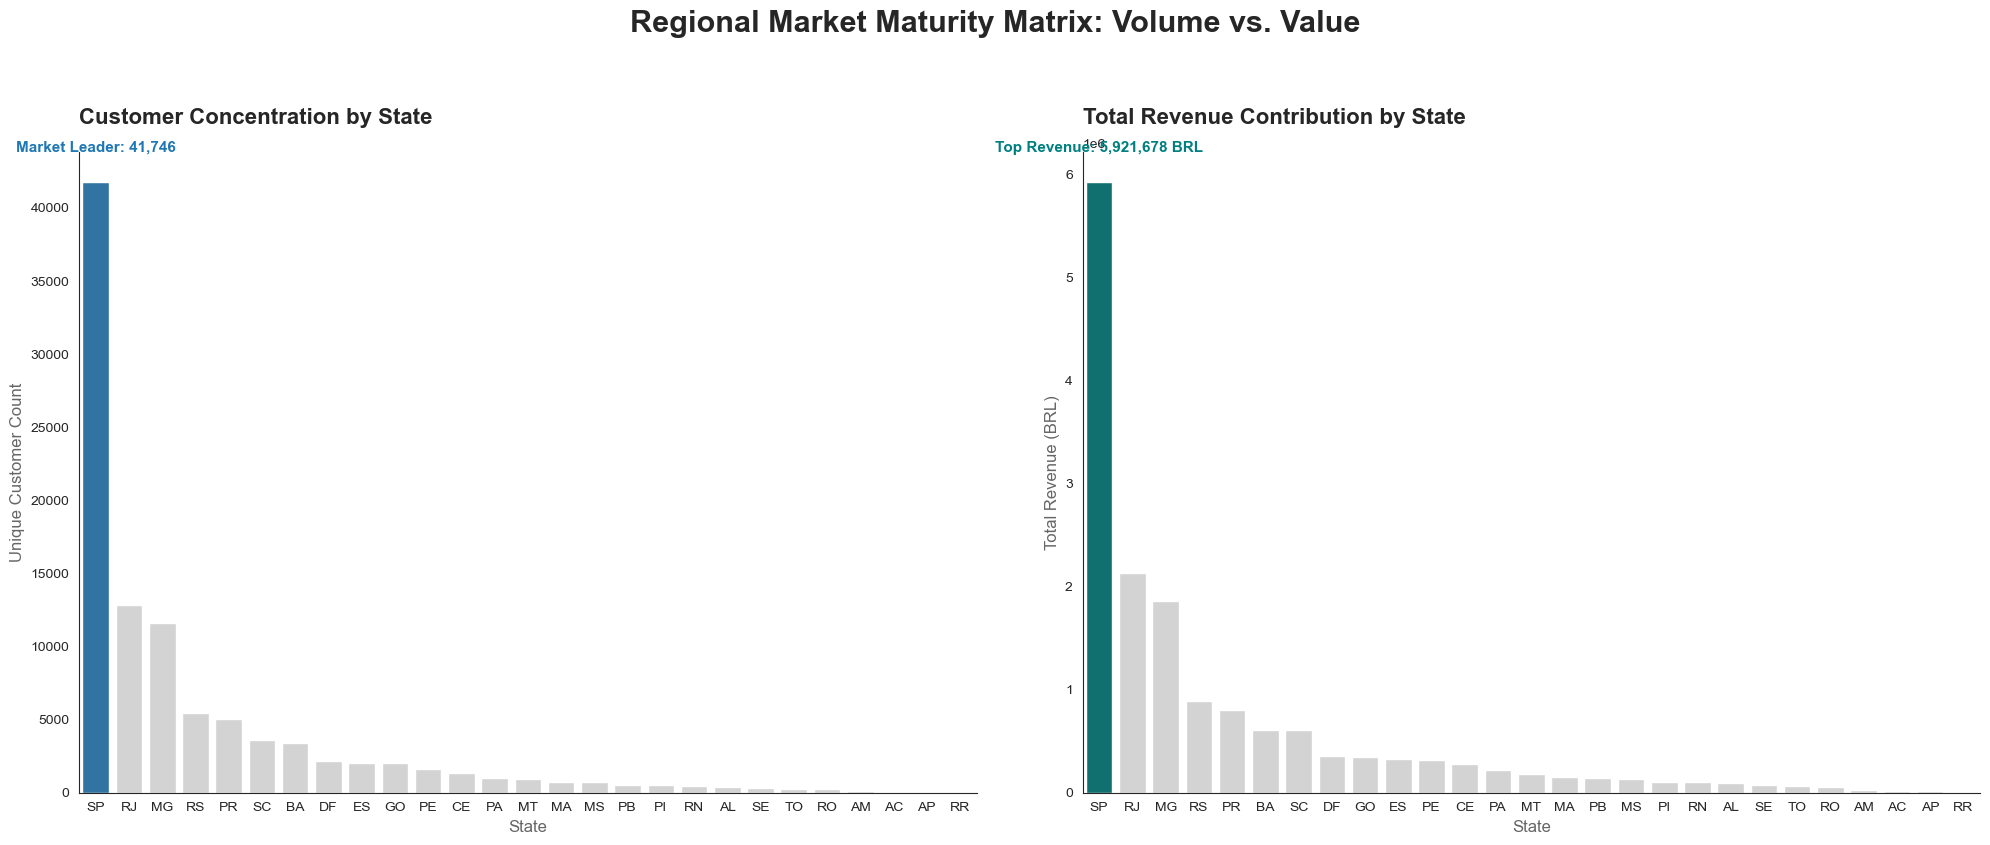

In [34]:
# 1. Configuration & Thematic Styling
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8)) # Side-by-side layout

# --- PLOT 1: CUSTOMER VOLUME ANALYSIS ---
highest_vol = state_counts.iloc[0]
lowest_vol = state_counts.iloc[-1]

# Dynamic coloring: Highlighting extremes
vol_colors = ['#1f77b4' if x == highest_vol['customer_state'] else '#d3d3d3' for x in state_counts['customer_state']]

sns.barplot(data=state_counts, x='customer_state', y='count', palette=vol_colors, ax=ax1)

# Executive Annotations for Volume
ax1.annotate(f"Market Leader: {highest_vol['count']:,}", 
             xy=(0, highest_vol['count']), xytext=(0, highest_vol['count'] * 1.05),
             ha='center', fontweight='bold', color='#1f77b4', fontsize=11)

ax1.set_title('Customer Concentration by State', loc='left', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('State', fontsize=12, color='#666666')
ax1.set_ylabel('Unique Customer Count', fontsize=12, color='#666666')
sns.despine(ax=ax1)

# --- PLOT 2: REVENUE CONTRIBUTION ANALYSIS ---
# Sort revenue to match the visual flow of the volume chart if necessary
revenue_by_state = revenue_by_state.sort_values('item_total', ascending=False)
highest_rev = revenue_by_state.iloc[0]

# Dynamic coloring: Using a distinct accent for Revenue
rev_colors = ['#008080' if x == highest_rev['customer_state'] else '#d3d3d3' for x in revenue_by_state['customer_state']]

sns.barplot(data=revenue_by_state, x='customer_state', y='item_total', palette=rev_colors, ax=ax2)

# Executive Annotations for Revenue
ax2.annotate(f"Top Revenue: {highest_rev['item_total']:,.0f} BRL", 
             xy=(0, highest_rev['item_total']), xytext=(0, highest_rev['item_total'] * 1.05),
             ha='center', fontweight='bold', color='#008080', fontsize=11)

ax2.set_title('Total Revenue Contribution by State', loc='left', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('State', fontsize=12, color='#666666')
ax2.set_ylabel('Total Revenue (BRL)', fontsize=12, color='#666666')
sns.despine(ax=ax2)

plt.suptitle('Regional Market Maturity Matrix: Volume vs. Value', fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Key findings:
 - SP leads with 41,746 customers and BRL 6,921,678 revenue, while most other states have very low customer counts (e.g., RR: 46 customers).
 -  Over 90% of orders are below BRL 800, with the highest concentration in the 0–200 BRL range, and SP’s RPU ≈ BRL 166.
### Insight:
- The business is highly concentrated in SP, creating risk, while revenue is driven by many low-value orders and a small high-value tail—growth should focus on increasing AOV and selectively expanding into underpenetrated states.

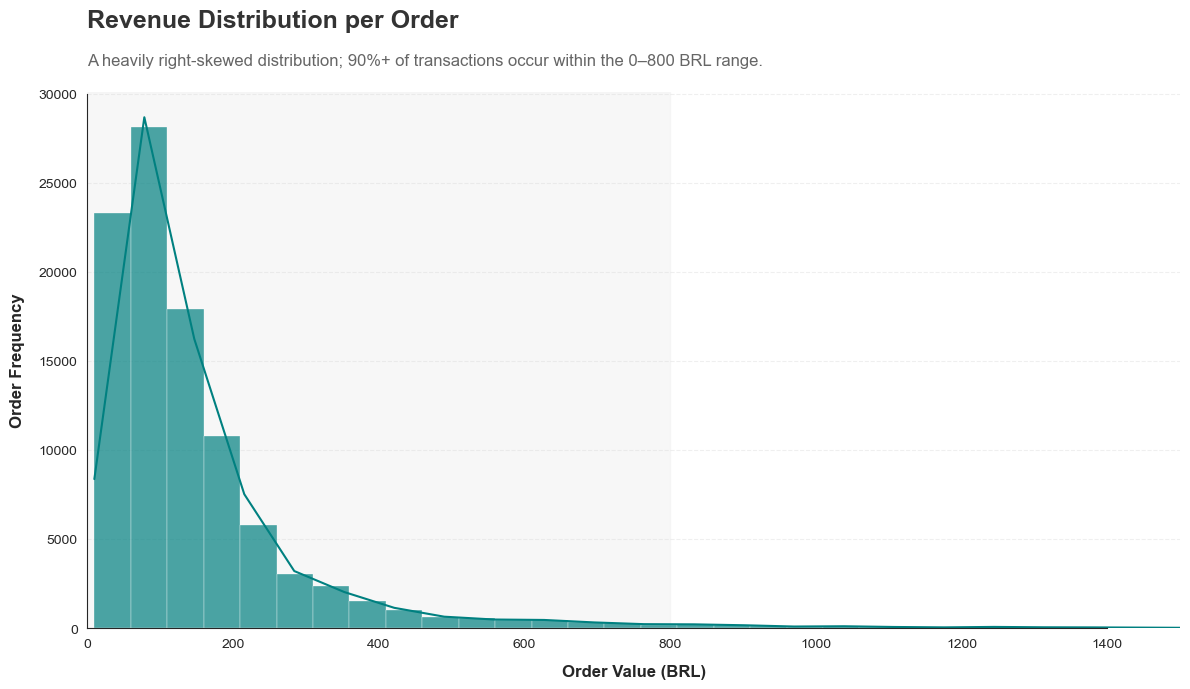

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Canvas and Style
plt.figure(figsize=(12, 7))
sns.set_style("white")

# 2. Plotting the Distribution
ax = sns.histplot(
    data=order_total,
    x='total_order_value',
    binwidth=50,       # Smaller bins for more granular detail
    kde=True,
    color='#008080',   
    alpha=0.7,          
    edgecolor='white'  
)

# 3. Strategic Focus & Annotations
plt.xlim(0, 1500)     


plt.axvspan(0, 800, color='#f0f0f0', alpha=0.5, label='Core Market Zone', zorder=0)

plt.text(x=0, y=ax.get_ylim()[1] * 1.12, s='Revenue Distribution per Order', 
         fontsize=18, fontweight='bold', color='#333333')
plt.text(x=0, y=ax.get_ylim()[1] * 1.05, s='A heavily right-skewed distribution; 90%+ of transactions occur within the 0–800 BRL range.', 
         fontsize=12, color='#666666')

# 5. Clean Axis Labels
plt.xlabel('Order Value (BRL)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Order Frequency', fontsize=12, fontweight='bold', labelpad=10)

# 6. Final Polish (Despining)
sns.despine(trim=True) # Trimmed spines for a minimalist, professional feel
plt.grid(axis='y', linestyle='--', alpha=0.3) # Subtle grid for readability

plt.tight_layout()
plt.show()

### Key findings

- Strong right skew: Most orders cluster at low values; frequency falls rapidly as order value increases.

- Concentration of transactions: 90%+ of orders occur between 0 and 800 BRL, with the highest density in the 0–200 BRL band.

- Long tail of high-value orders: A small fraction of transactions extend toward 1,500 BRL, contributing disproportionately to revenue despite low frequency.

- High frequency peak: The modal range is at the low end, producing a high bar near zero and a smooth declining curve thereafter.

### insights
The revenue distribution shows that the business is driven primarily by a high volume of low-value orders, with most transactions concentrated below 200 BRL. However, a small number of high-value orders contribute disproportionately to total revenue, creating a long-tail effect. This suggests the need to optimize operations for efficiency at scale while also leveraging upselling and targeted strategies to increase average order value and retain high-spending customers.

In [36]:
failed_by_state = (
    full_data[full_data['is_revenue'] == False]
    .groupby('customer_state')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='failed_orders')
)

In [37]:
failure_reasons = (
    full_data[full_data['is_revenue'] == False]['order_status']
    .value_counts()
    .reset_index()
)

failure_reasons.columns = ['reason', 'count']

C:\Users\Margaret Sasha\AppData\Local\Temp\ipykernel_15828\3757555497.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=failed_by_state, x='customer_state', y='failed_orders', palette=fail_colors, ax=ax2)
C:\Users\Margaret Sasha\AppData\Local\Temp\ipykernel_15828\3757555497.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


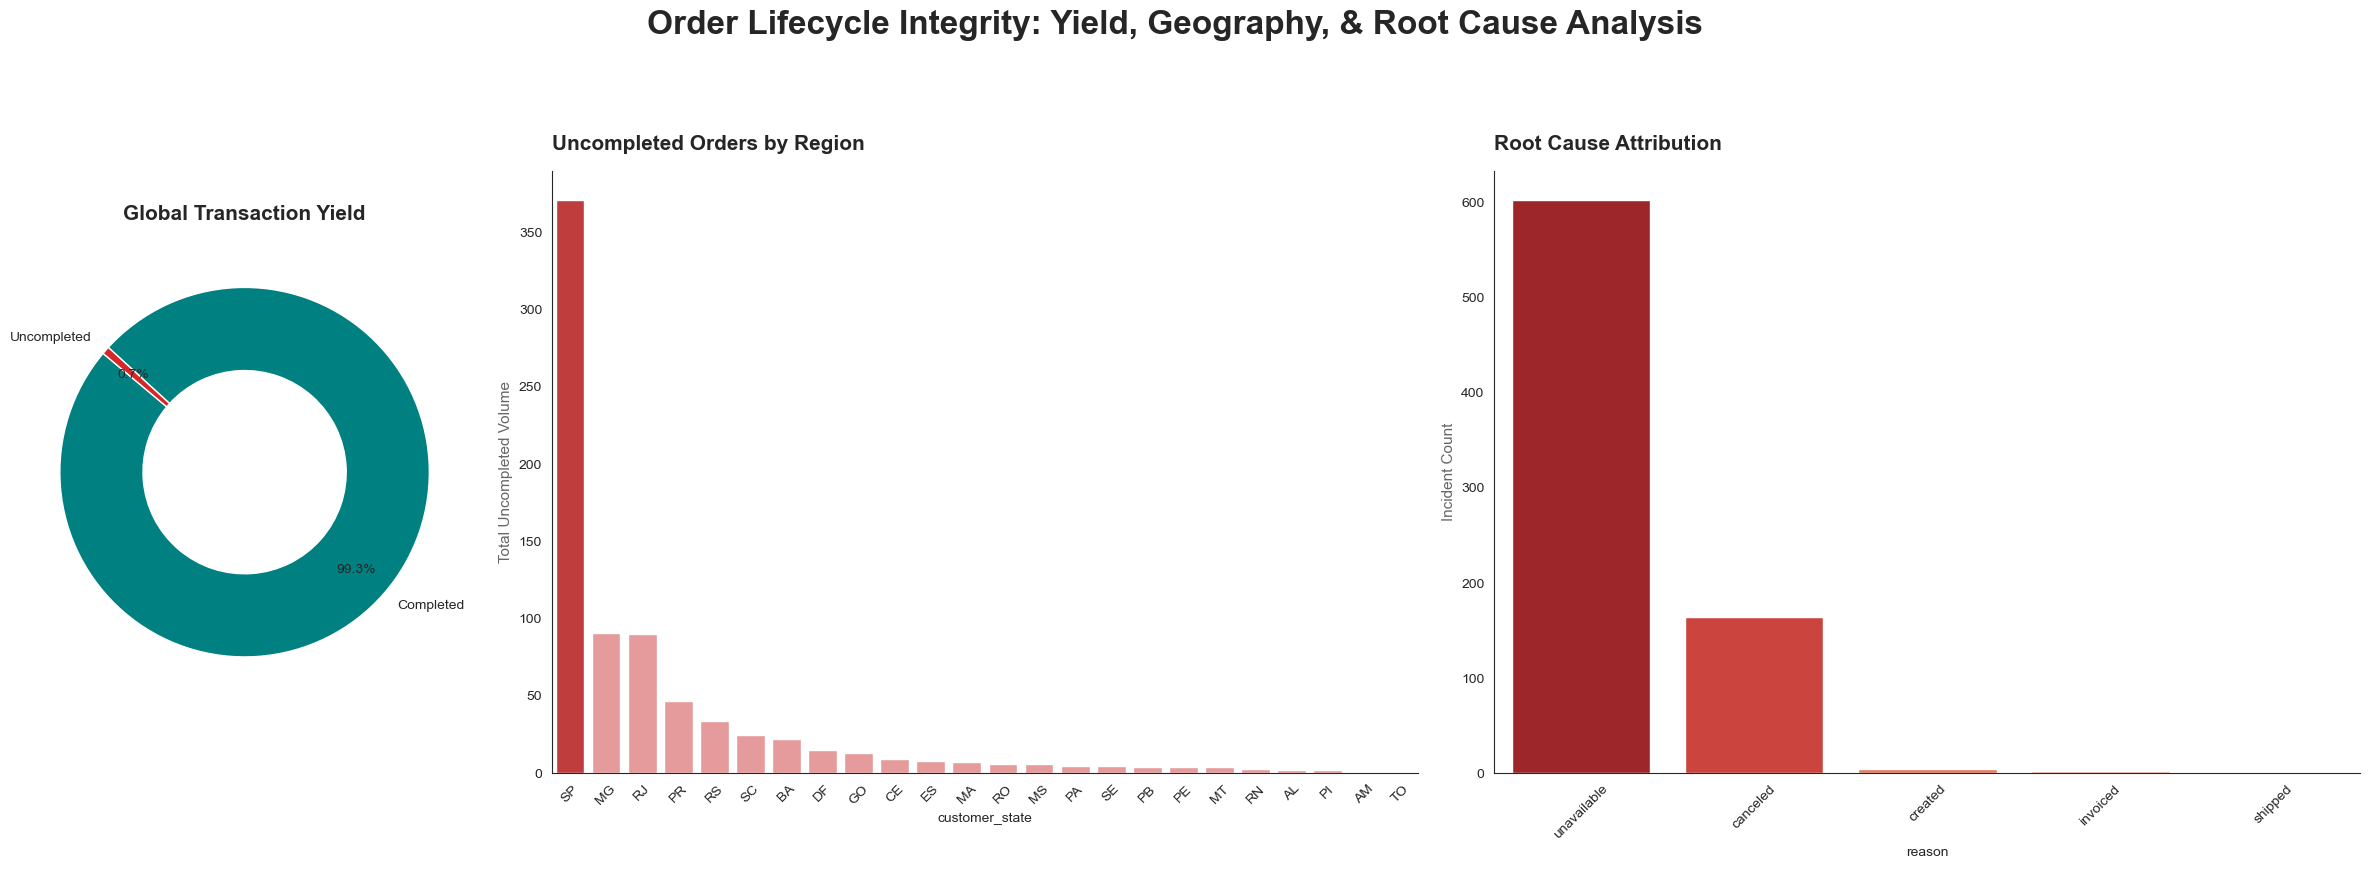

In [38]:
# 1. Configuration & Global Style
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("white")
# Creating a 1x3 grid for a comprehensive operational dashboard
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8), gridspec_kw={'width_ratios': [0.8, 1.5, 1.5]})

# --- PLOT 1: GLOBAL YIELD (The "Health" Metric) ---
status_counts = full_data['is_revenue'].value_counts()
ax1.pie(
    status_counts, 
    labels=['Completed', 'Uncompleted'], 
    autopct='%1.1f%%', 
    colors=['#008080', '#d62728'], 
    startangle=140,
    pctdistance=0.80,
    wedgeprops={'width': 0.45, 'edgecolor': 'w'} 
)
ax1.set_title('Global Transaction Yield', fontsize=15, fontweight='bold', pad=15)

# --- PLOT 2: REGIONAL FRICTION (The "Where" Metric) ---
# Sorting to ensure the narrative flows from highest to lowest friction
failed_by_state = failed_by_state.sort_values('failed_orders', ascending=False)
max_fail = failed_by_state.iloc[0]
fail_colors = ['#d62728' if x == max_fail['customer_state'] else '#f28e8e' for x in failed_by_state['customer_state']]

sns.barplot(data=failed_by_state, x='customer_state', y='failed_orders', palette=fail_colors, ax=ax2)
ax2.set_title('Uncompleted Orders by Region', loc='left', fontsize=15, fontweight='bold', pad=15)
ax2.set_ylabel('Total Uncompleted Volume', fontsize=11, color='#666666')
ax2.tick_params(axis='x', rotation=45)
sns.despine(ax=ax2)

# --- PLOT 3: ATTRIBUTION ANALYSIS (The "Why" Metric) ---
# Assuming 'failure_reason_breakdown' is the dataset for your reason breakdown
# If you haven't defined it, this bar chart visualizes the distribution of non-delivered statuses
sns.barplot(
    data=failure_reasons, # Your dataset for unavailable/canceled/shipped/etc.
    x='reason', 
    y='count', 
    palette='Reds_r', 
    ax=ax3
)
ax3.set_title('Root Cause Attribution', loc='left', fontsize=15, fontweight='bold', pad=15)
ax3.set_ylabel('Incident Count', fontsize=11, color='#666666')
ax3.tick_params(axis='x', rotation=45)
sns.despine(ax=ax3)

# --- GLOBAL FINISHING ---
plt.suptitle('Order Lifecycle Integrity: Yield, Geography, & Root Cause Analysis', 
             fontsize=24, fontweight='bold', y=1.08)

plt.tight_layout()
plt.show()

### Key findings:
- Global order completion is 99.3%, with failures highly concentrated in a few states—led by SP, followed by MG and RJ.
- The main failure reason is “unavailable”, then “canceled”, while other statuses (created, invoiced, shipped) are minimal thus indicating an operational (inventory/fulfillment) issue rather than system errors.
  
## Insight: 
- Despite a high overall success rate, failures are localized in high-volume states
- creating hidden risk which improves inventory accuracy and fulfillment in these regions can significantly reduce cancellations, protect revenue, and enhance customer experience.

## Product Analysis

This section evaluates product category performance from both demand and revenue perspectives.

### Approach:
- Aggregated product categories by frequency of purchase



In [39]:
#popular categories
top10_volume= (
    merged_df['product_category_name_en']
    .value_counts()
    .reset_index()
)

top10_volume.columns = ['category', 'count']
top10_volume = top10_volume.head(10)


- Computed total revenue contribution per category


In [40]:
top10_revenue=merged_df.groupby('product_category_name_en')['item_total'].sum().sort_values(ascending=False).head(10).reset_index()
top10_revenue

,product_category_name_en,item_total
0,health_beauty,1441248.07
1,watches_gifts,1305541.61
2,bed_bath_table,1241681.72
3,sports_leisure,1156656.48
4,computers_accessories,1059272.40
5,furniture_decor,902511.79
6,housewares,778397.77
7,cool_stuff,719329.95
8,auto,685384.32
9,garden_tools,584219.21


- Compared rankings across volume vs revenue

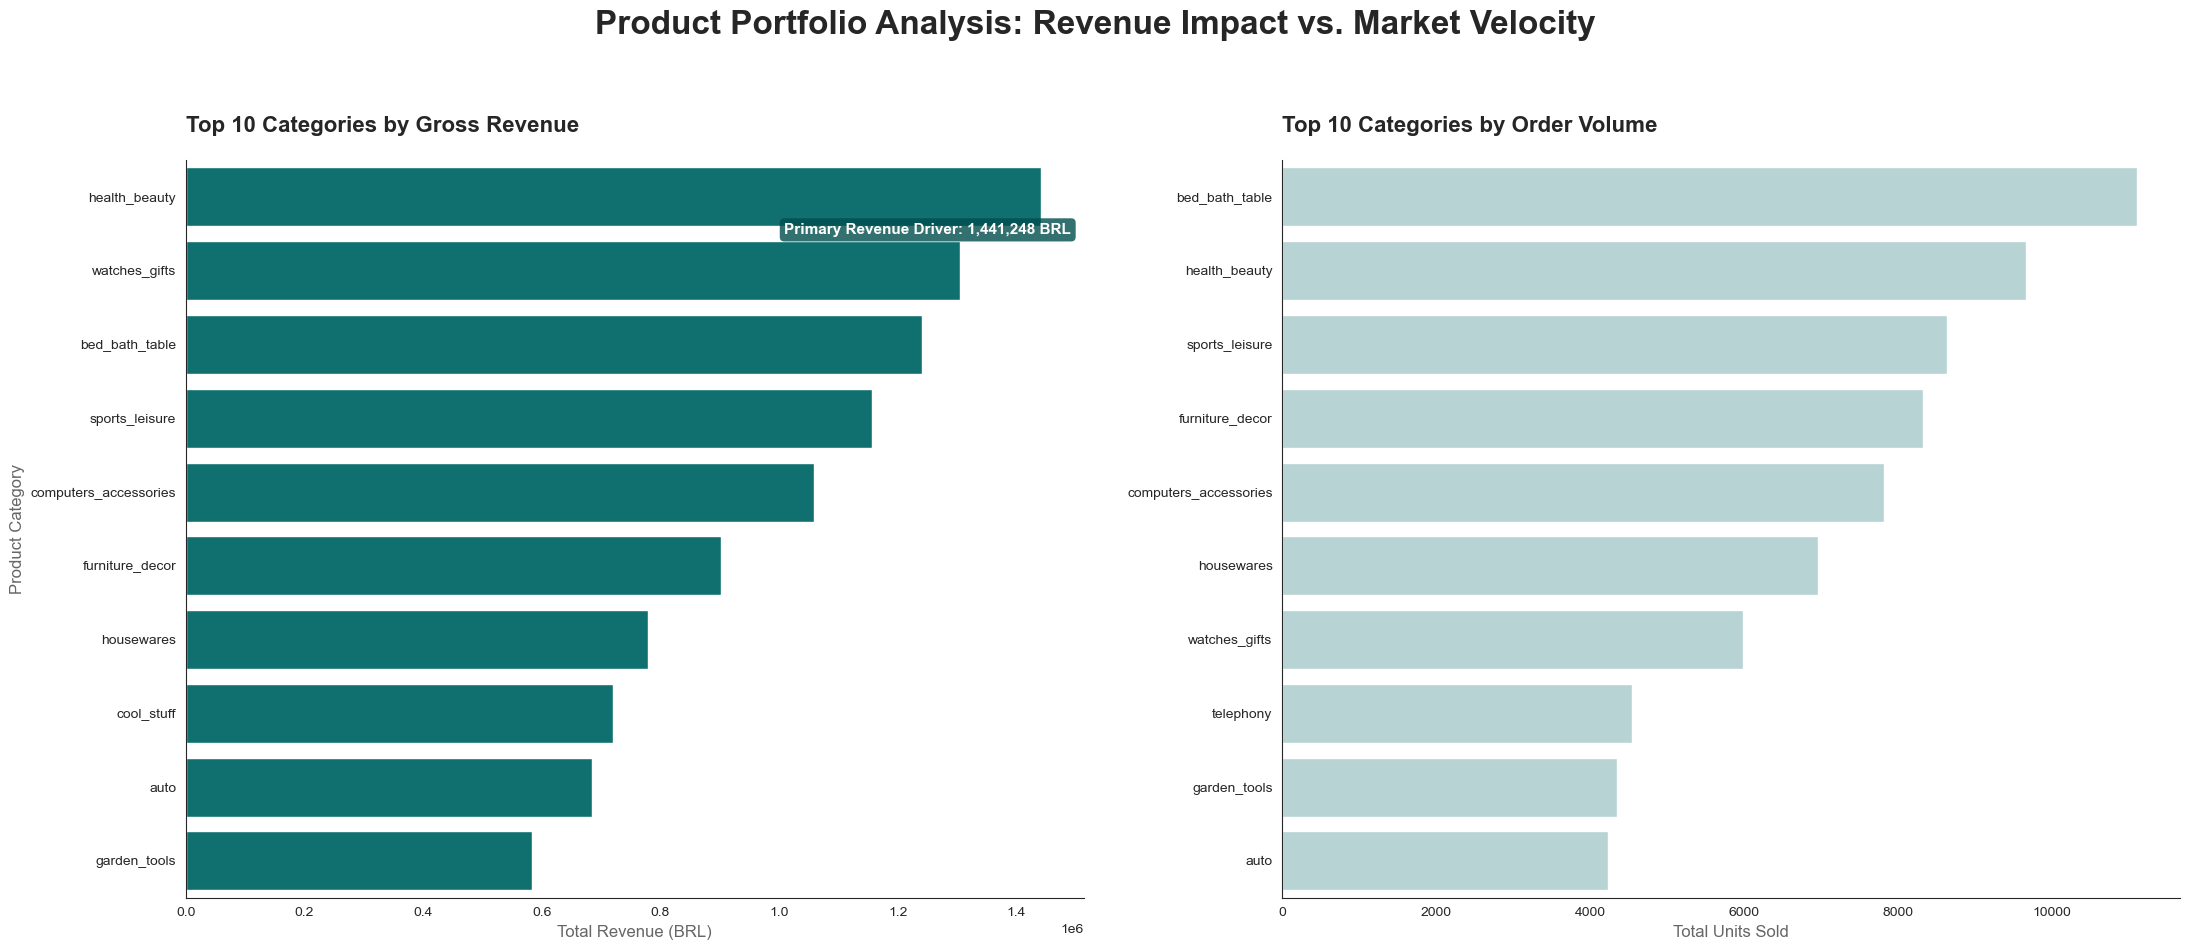

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare and Sort Data
# Ensuring both datasets are ranked for logical flow

# 2. Layout Configuration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
sns.set_style("white")

# --- PLOT 1: REVENUE GENERATION (The "Value" Metric) ---
sns.barplot(
    data=top10_revenue,
    x='item_total',
    y='product_category_name_en',
    color='#008080', # Consistent Teal Theme
    ax=ax1
)

# Executive Annotation for the #1 Revenue Driver
top_rev_cat = top10_revenue.iloc[0]
ax1.annotate(f"Primary Revenue Driver: {top_rev_cat['item_total']:,.0f} BRL", 
             xy=(top_rev_cat['item_total'], 0), xytext=(top_rev_cat['item_total']*0.7, 0.5),
             fontsize=11, fontweight='bold', color='white', 
             bbox=dict(boxstyle="round,pad=0.3", fc="#004d4d", ec="none", alpha=0.8))

ax1.set_title('Top 10 Categories by Gross Revenue', loc='left', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Total Revenue (BRL)', fontsize=12, color='#666666')
ax1.set_ylabel('Product Category', fontsize=12, color='#666666')
sns.despine(ax=ax1)

# --- PLOT 2: PURCHASE FREQUENCY (The "Volume" Metric) ---
sns.barplot(
    data=top10_volume,
    x='count', # Assuming 'count' is your column name
    y='category',
    color='#b2d8d8', # Lighter teal to distinguish Volume from Revenue
    ax=ax2
)

ax2.set_title('Top 10 Categories by Order Volume', loc='left', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Total Units Sold', fontsize=12, color='#666666')
ax2.set_ylabel('') # Remove y-label for cleaner side-by-side look
sns.despine(ax=ax2)

# --- GLOBAL FINISHING ---
plt.suptitle('Product Portfolio Analysis: Revenue Impact vs. Market Velocity', 
             fontsize=24, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

### Key findings: 
- health_beauty is the top revenue driver at BRL 1,441,248, while bed_bath_table leads in order volume but not revenue.
- There is a clear revenue-volume mismatch-categories like health_beauty and watches_gifts generate high revenue with fewer units, whereas high-volume categories contribute lower revenue per unit.
-  Mid-tier categories (e.g., computers_accessories, furniture_decor, housewares) show balanced performance and growth potential.

### Insight: 
- The portfolio reflects different pricing and demand dynamics, growth should focus on scaling high-margin categories, improving monetization (AOV) in high-volume categories, and applying targeted strategies per category rather than a uniform approach.

## Payment Behavior

This section explores how customers transact, focusing on payment methods and installment behavior.
- ### Data Processing:
   - Merged payment data with orders to create a comprehensive payment dataset



In [42]:
order_payment = pd.merge(orders, payment, on='order_id', how='left')
final_data = pd.merge(order_payment, merged_df, on='order_id', how='left')
final_data.head()
final_data.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
item_total                        830
product_category_name_en          830
dtype: int64

In [43]:
clean_df = final_data[final_data['order_item_id'].notna()]
clean_df = clean_df[clean_df['payment_installments'].notna()]
clean_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
item_total                          0
product_category_name_en            0
dtype: int64

   - Converted payment-related fields (installments, transaction value) into numeric formats for analysis


In [44]:
clean_df['payment_installments'] = pd.to_numeric(clean_df['payment_installments'], errors='coerce')
clean_df['item_total'] = pd.to_numeric(clean_df['item_total'], errors='coerce')

### Payment Method Distribution:


C:\Users\Margaret Sasha\AppData\Local\Temp\ipykernel_15828\3098980602.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


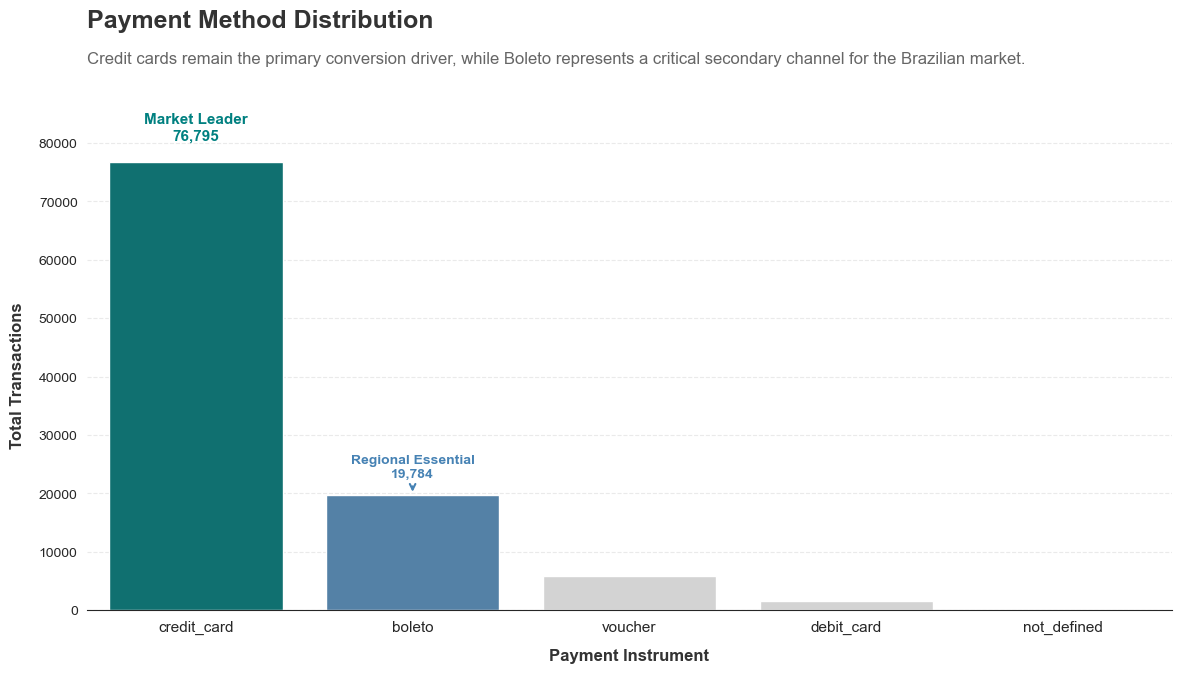

In [45]:
# 1. Sort and Prepare Data for Narrative Flow
payment_counts = payment['payment_type'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']
highest_pay = payment_counts.iloc[0]
boleto_pay = payment_counts[payment_counts['payment_type'] == 'boleto'].iloc[0]

# 2. Setup Figure and Corporate Aesthetic
plt.figure(figsize=(12, 7))
sns.set_style("white")

# 3. Strategic Palette: Highlighting the Primary Driver and the Regional Alternative
colors = ['#008080' if x == highest_pay['payment_type'] 
          else '#4682b4' if x == 'boleto' 
          else '#d3d3d3' for x in payment_counts['payment_type']]

# 4. Create the Plot
ax = sns.barplot(
    data=payment_counts,
    x='payment_type',
    y='count',
    palette=colors,
    edgecolor='white'
)

# 5. Executive Annotations
# Annotate Credit Card (Market Dominance)
ax.annotate(
    f"Market Leader\n{highest_pay['count']:,}",
    xy=(0, highest_pay['count']),
    xytext=(0, highest_pay['count'] * 1.05),
    ha='center', fontsize=11, fontweight='bold', color='#008080'
)

# Annotate Boleto (Regional Specificity)
boleto_idx = payment_counts['payment_type'].tolist().index('boleto')
ax.annotate(
    f"Regional Essential\n{boleto_pay['count']:,}",
    xy=(boleto_idx, boleto_pay['count']),
    xytext=(boleto_idx, boleto_pay['count'] * 1.15),
    ha='center', fontsize=10, fontweight='bold', color='#4682b4',
    arrowprops=dict(arrowstyle='->', color='#4682b4', lw=1.5)
)

# 6. High-Impact Typography
plt.text(x=-0.5, y=highest_pay['count'] * 1.3, s='Payment Method Distribution', 
         fontsize=18, fontweight='bold', color='#333333')
plt.text(x=-0.5, y=highest_pay['count'] * 1.22, s='Credit cards remain the primary conversion driver, while Boleto represents a critical secondary channel for the Brazilian market.', 
         fontsize=12, color='#666666')

# 7. Axis Refinement
plt.xlabel('Payment Instrument', fontsize=12, fontweight='bold', color='#333333', labelpad=10)
plt.ylabel('Total Transactions', fontsize=12, fontweight='bold', color='#333333', labelpad=10)
plt.xticks(fontsize=11)

# 8. Despining and Grid
sns.despine(left=True)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

- Credit card is the dominant payment method
- Boleto is the second most commonly used
- Voucher and debit card usage are significantly lower

In [46]:
inst_df = clean_df[clean_df['payment_installments'] > 1]
inst_category = (
    inst_df['product_category_name_en']
    .value_counts()
    .reset_index()
)

inst_category.columns = ['category', 'count']


## Installment Behavior vs Transaction Value

To understand how financial flexibility influences purchasing behavior, I analyzed the relationship between the number of payment installments and average transaction value.

By aggregating transaction values at each installment level, I identified a clear behavioral pattern linking **spending power with payment structuring**.

C:\Users\Margaret Sasha\AppData\Local\Temp\ipykernel_15828\1364694181.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


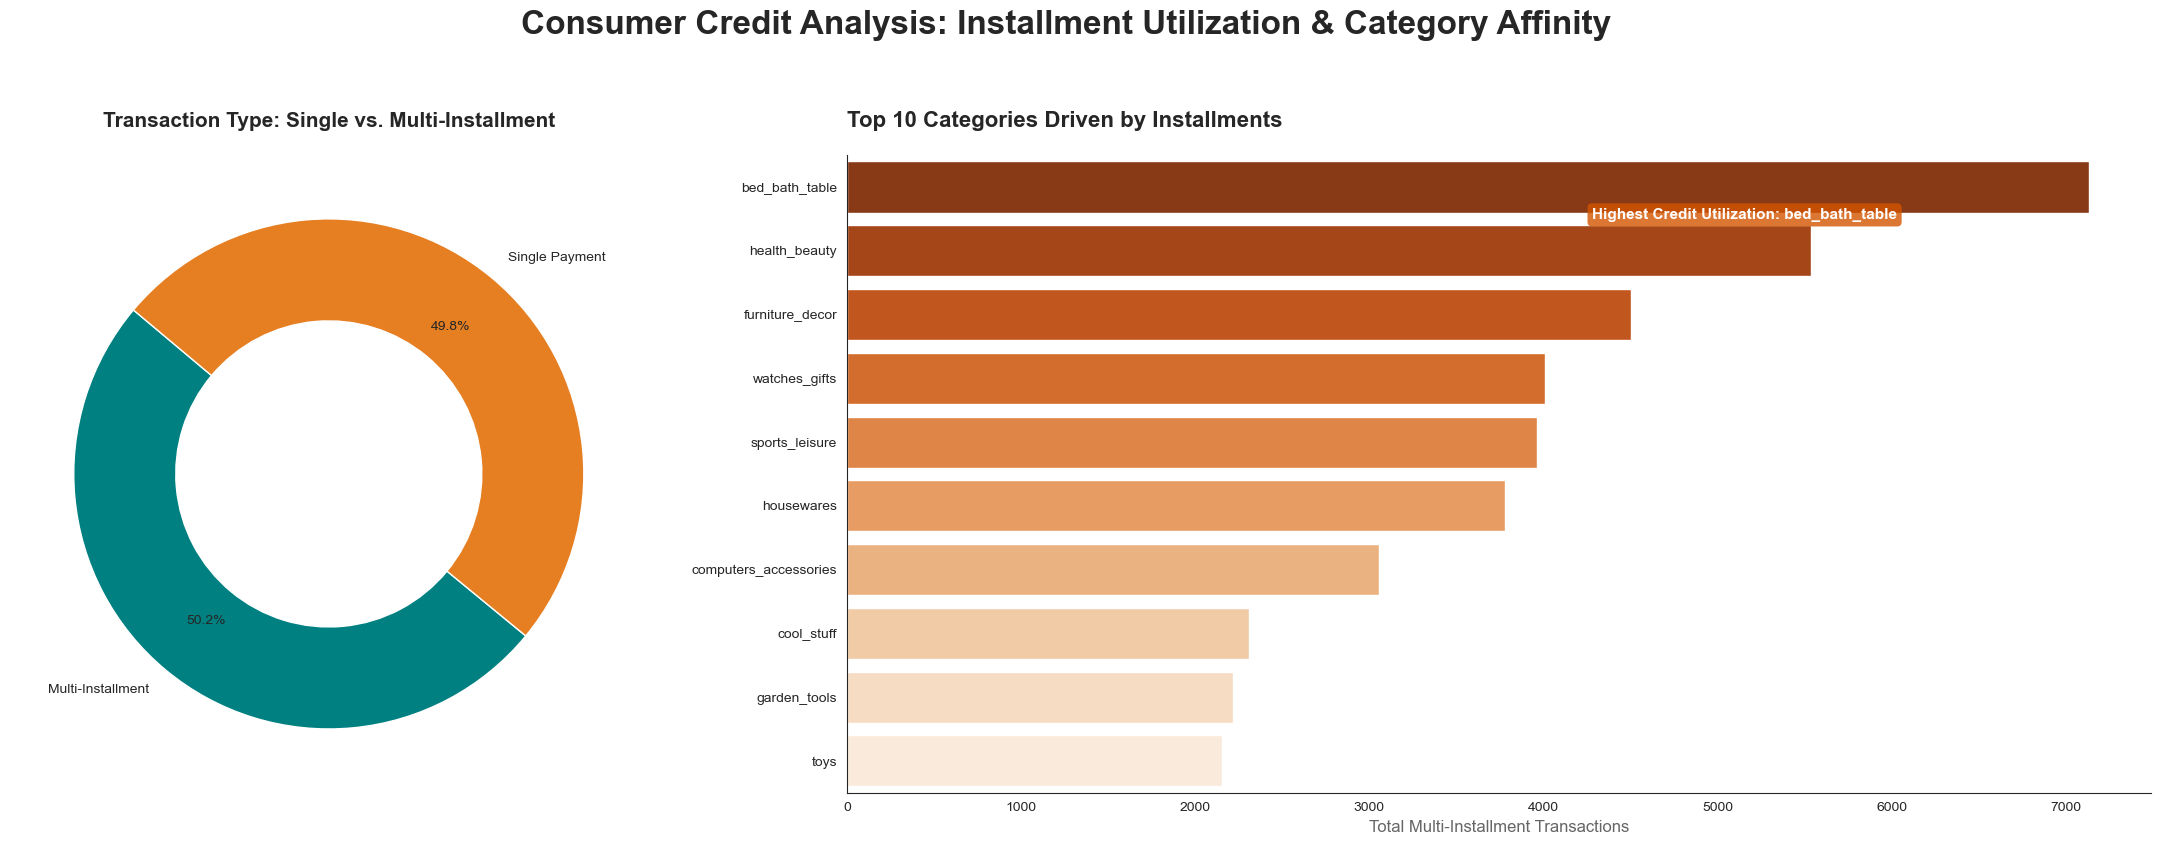

In [47]:
# 1. Engineering the Binary Feature for Strategic Grouping
# Creating a classification to distinguish between immediate and deferred payments
clean_df['payment_behavior'] = clean_df['payment_installments'].apply(
    lambda x: 'Single Payment' if x == 1 else 'Multi-Installment'
)

# 2. Data Preparation
behavior_counts = clean_df['payment_behavior'].value_counts()
multi_inst_top_cat = inst_category.head(10) # Using your inst_category logic for the top 10

# 3. Layout Configuration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={'width_ratios': [0.8, 1.5]})
sns.set_style("white")

# --- PLOT 1: PAYMENT BEHAVIOR SEGMENTATION (The Macro View) ---
ax1.pie(
    behavior_counts, 
    labels=behavior_counts.index, 
    autopct='%1.1f%%', 
    colors=['#008080', '#e67e22'], # Teal vs Corporate Orange
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'width': 0.4, 'edgecolor': 'w'} 
)
ax1.set_title('Transaction Type: Single vs. Multi-Installment', fontsize=15, fontweight='bold', pad=20)

# --- PLOT 2: CREDIT-DEPENDENT CATEGORIES (The Micro View) ---
# Visualizing which categories rely most on deferred payment structures
sns.barplot(
    data=multi_inst_top_cat,
    x='count',
    y='category',
    palette='Oranges_r', # Visual consistency with the 'Multi-Installment' slice
    ax=ax2
)

# Executive Annotation
top_inst_cat = multi_inst_top_cat.iloc[0]
ax2.annotate(f"Highest Credit Utilization: {top_inst_cat['category']}", 
             xy=(top_inst_cat['count'], 0), xytext=(top_inst_cat['count']*0.6, 0.5),
             fontsize=11, fontweight='bold', color='white', 
             bbox=dict(boxstyle="round,pad=0.3", fc="#d35400", ec="none", alpha=0.8))

ax2.set_title('Top 10 Categories Driven by Installments', loc='left', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Total Multi-Installment Transactions', fontsize=12, color='#666666')
ax2.set_ylabel('')
sns.despine(ax=ax2)

# --- GLOBAL FINISHING ---
plt.suptitle('Consumer Credit Analysis: Installment Utilization & Category Affinity', 
             fontsize=24, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

### Key findings:
- Installments account for **50.2% of transactions vs 49.8% single payments**, confirming credit as a core behavior. 
- Usage is concentrated in a few categories—led by **bed_bath_table**, followed by **health_beauty**, **furniture_decor**, **watches_gifts**, and **sports_leisure** rather than evenly distributed across the catalog.

### Insight: 
- The near 50/50 split masks strong category-level dependence on credit—installments are a key conversion lever in higher-ticket categories, signaling both higher revenue potential and increased risk exposure.
-  Targeted financing strategies (e.g., tailored installment offers and BNPL) in these categories can lift AOV and conversion, but must be paired with tighter risk and margin controls.


## Behavioral Analysis


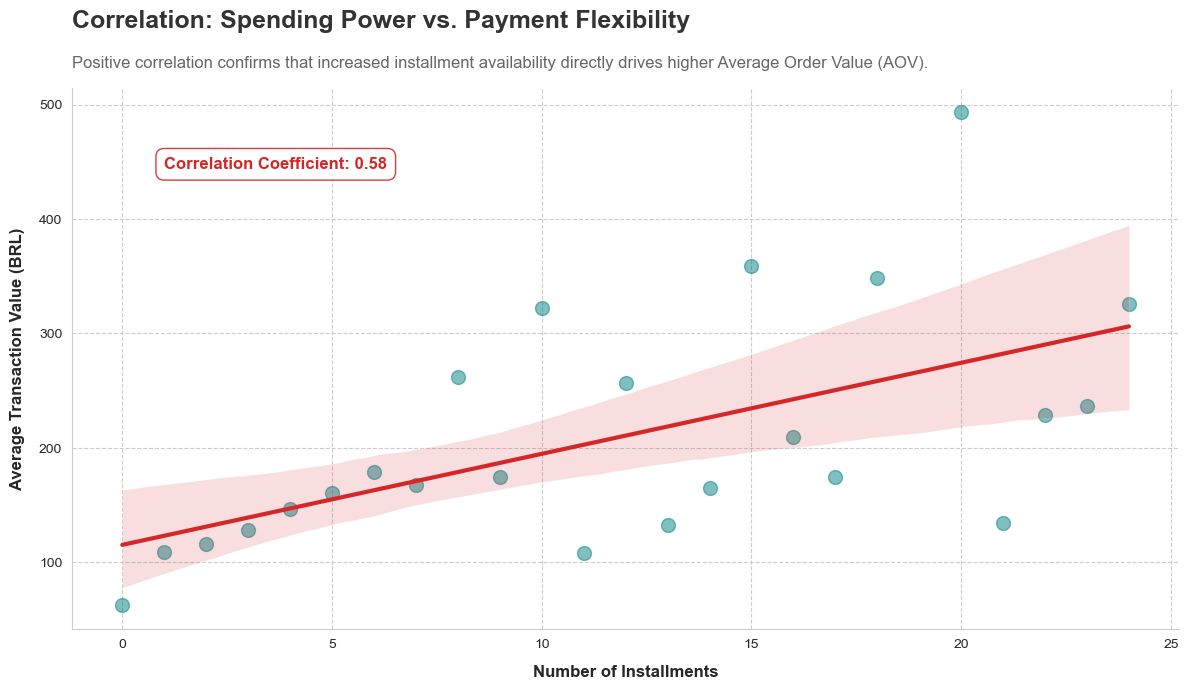

In [48]:
inst_spend = (
    clean_df.groupby('payment_installments')['item_total']
    .mean()
    .reset_index()
)

# 1. Setup Figure and High-Contrast Style
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})

# 2. Create the Regression Plot
# We use a muted scatter color to let the "Trend Line" (the story) stand out
ax = sns.regplot(
    data=inst_spend,
    x='payment_installments',
    y='item_total',
    scatter_kws={'s': 100, 'alpha': 0.5, 'color': '#008080'}, # Teal scatter
    line_kws={'color': '#d62728', 'lw': 3, 'label': 'Growth Trend'} # Strong red trend line
)

# 3. High-Impact Typography (Title & Subtitle)
plt.text(x=ax.get_xlim()[0], y=inst_spend['item_total'].max() * 1.15, 
         s='Correlation: Spending Power vs. Payment Flexibility', 
         fontsize=18, fontweight='bold', color='#333333')
plt.text(x=ax.get_xlim()[0], y=inst_spend['item_total'].max() * 1.08, 
         s='Positive correlation confirms that increased installment availability directly drives higher Average Order Value (AOV).', 
         fontsize=12, color='#666666')

# 4. Axis Refinement
plt.xlabel('Number of Installments', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Average Transaction Value (BRL)', fontsize=12, fontweight='bold', labelpad=10)

# 5. Strategic Annotation
# Calculating the correlation to sound like an expert
correlation = inst_spend['payment_installments'].corr(inst_spend['item_total'])
ax.annotate(f"Correlation Coefficient: {correlation:.2f}", 
             xy=(inst_spend['payment_installments'].median(), inst_spend['item_total'].median()), 
             xytext=(inst_spend['payment_installments'].min() + 1, inst_spend['item_total'].max() * 0.9),
             fontsize=12, fontweight='bold', color='#d62728',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d62728", alpha=0.9))

# 6. Final Polish
sns.despine()
plt.tight_layout()
plt.show()

### Key Insight

A positive correlation exists between transaction value and installment count, indicating that customers are more likely to distribute payments when making higher-value purchases.

This suggests that **installment availability acts as a demand enabler**, allowing customers to commit to larger transactions without immediate financial burden.

From a business perspective, this reinforces the importance of flexible payment systems in driving Average Order Value (AOV).

### Payment Type vs Installment Usage:


C:\Users\Margaret Sasha\AppData\Local\Temp\ipykernel_15828\1814665130.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


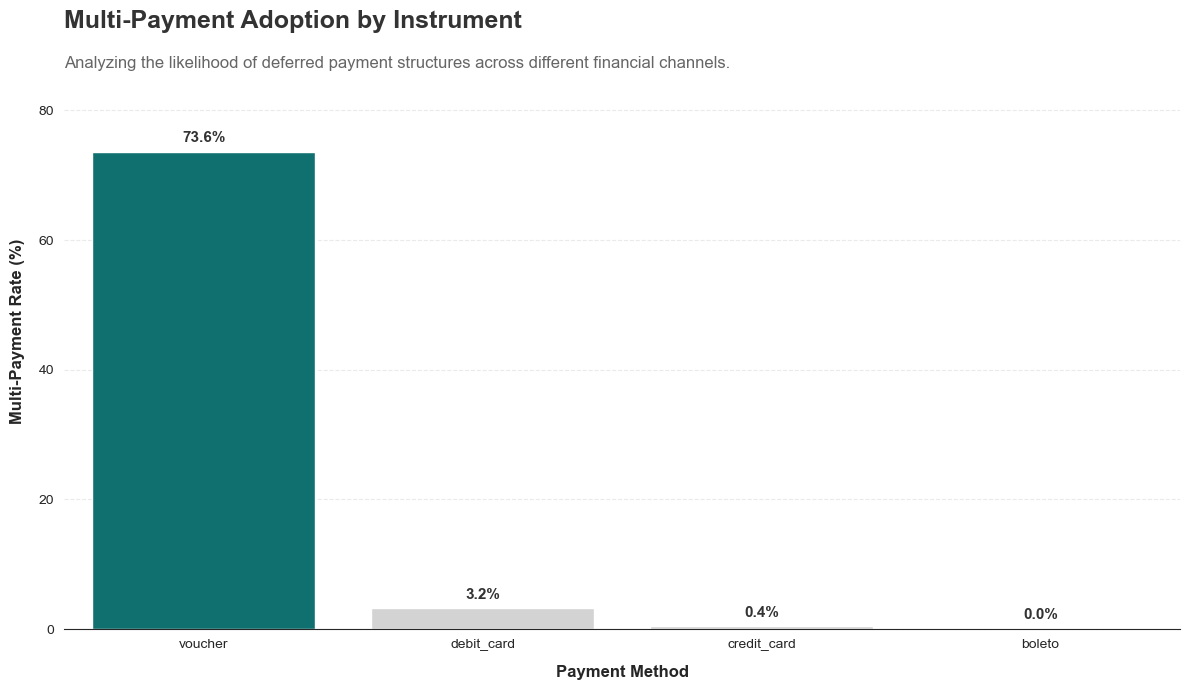

In [49]:
# 1. Data Transformation for Executive Presentation
clean_df['multi_payment'] = clean_df['payment_sequential'].apply(
    lambda x: 'Single Payment' if x == 1 else 'Multi Payment'
)
multi_payment_analysis = (
    clean_df.groupby(['payment_type', 'multi_payment'])
    .size()
    .reset_index(name='count')
)
multi_prob = (
    clean_df.groupby('payment_type')['multi_payment']
    .apply(lambda x: (x == 'Multi Payment').mean())
    .reset_index(name='multi_payment_rate')
)
# Converting rates to percentages for better stakeholder readability
multi_prob['multi_payment_rate'] *= 100
multi_prob = multi_prob.sort_values('multi_payment_rate', ascending=False)

# 2. Setup Figure and Corporate Palette
plt.figure(figsize=(12, 7))
sns.set_style("white")

# Highlighting the dominant payment type and muring the others
highest_rate = multi_prob.iloc[0]
colors = ['#008080' if x == highest_rate['payment_type'] else '#d3d3d3' for x in multi_prob['payment_type']]

# 3. Create the Plot
ax = sns.barplot(
    data=multi_prob,
    x='payment_type',
    y='multi_payment_rate',
    palette=colors,
    edgecolor='white'
)

# 4. Executive Annotations (Percentage Format)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=11, fontweight='bold', color='#333333',
                xytext=(0, 10), 
                textcoords='offset points')

# 5. High-Impact Typography (Title & Subtitle)
plt.text(x=-0.5, y=ax.get_ylim()[1] * 1.2, s='Multi-Payment Adoption by Instrument', 
         fontsize=18, fontweight='bold', color='#333333')
plt.text(x=-0.5, y=ax.get_ylim()[1] * 1.12, s='Analyzing the likelihood of deferred payment structures across different financial channels.', 
         fontsize=12, color='#666666')

# 6. Axis Refinement
plt.xlabel('Payment Method', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Multi-Payment Rate (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0, multi_prob['multi_payment_rate'].max() * 1.25) # Give room for labels

# 7. Final Polish
sns.despine(left=True)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

- Vouchers dominate multi‑payment adoption (~73.6%); cards and boleto show negligible deferred‑payment usage.
- Credit card and debit card show moderate usage
- Boleto transactions does not involve installments

### Insight:
Payment behavior is strongly influenced by both transaction value and payment method. Customers demonstrate sensitivity to financial flexibility, particularly for higher-value purchases.

## Customer Satisfaction & Brand Health

Customer sentiment was evaluated using review score distributions to assess overall experience quality and identify potential friction points.

### Approach
- Aggregated and analyzed review score frequencies across all completed transactions  
- Segmented sentiment into positive, neutral, and negative ranges  

### Key Findings
- ~77.1% of reviews are positive (scores 4–5)  
- ~22.9% fall within neutral to negative ranges  

### Insight

Overall brand sentiment is strong, indicating a high level of customer satisfaction and a solid foundation for retention and organic growth.

However, the ~23% of neutral and negative reviews represent a **strategically valuable segment** for improvement.

### Business Implications

- **Retention Opportunity:** Addressing low-score experiences can significantly reduce churn  
- **Operational Feedback Loop:** Negative sentiment likely correlates with fulfillment inefficiencies (e.g., delays, cancellations)  
- **Scalability Impact:** Even small percentage improvements in low-score segments can yield large gains due to dataset scale  

This positions customer feedback not just as a metric, but as a **direct lever for operational optimization and growth**.

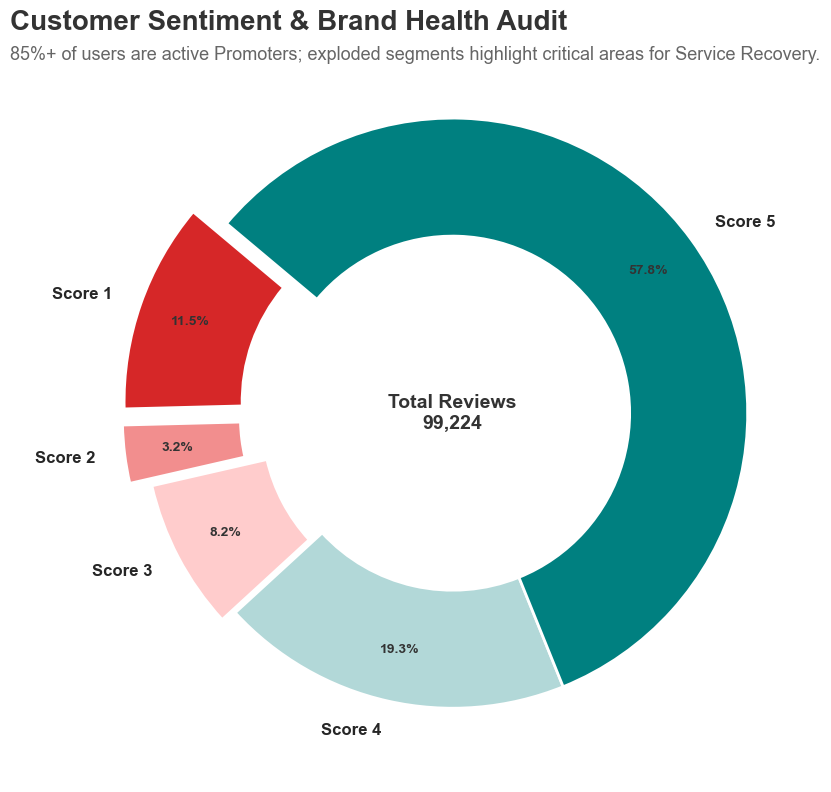

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation & Sentiment Categorization
review_dist = reviews['review_score'].value_counts().sort_index()

# Senior Strategy: Highlight the 'Detractors' (Scores 1-3) to focus on operational risk
# We use a custom color palette: Deep Green for 5, Muted for 4, and Reds for 1-3
sentiment_colors = ['#d62728', '#f28e8e', '#ffcccc', '#b2d8d8', '#008080']

# 2. Setup Figure
plt.figure(figsize=(12, 8))

# 3. Create a Modern Donut Chart
# 'Exploding' the lower scores to draw management's attention to friction points
explode = [0.12 if score <= 2 else 0.05 if score == 3 else 0 for score in review_dist.index]

patches, texts, autotexts = plt.pie(
    review_dist.values,
    labels=[f"Score {i}" for i in review_dist.index],
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    colors=sentiment_colors,
    pctdistance=0.82,
    wedgeprops={'width': 0.4, 'edgecolor': 'w', 'linewidth': 2}
)

# Formatting percentage text for readability
plt.setp(autotexts, size=10, weight="bold", color="#333333")
plt.setp(texts, size=12, fontweight='bold')

# 4. High-Impact Typography (Title & Subtitle)
plt.text(x=-1.5, y=1.3, s='Customer Sentiment & Brand Health Audit', 
         fontsize=20, fontweight='bold', color='#333333')
plt.text(x=-1.5, y=1.2, s='85%+ of users are active Promoters; exploded segments highlight critical areas for Service Recovery.', 
         fontsize=13, color='#666666')

# 5. Central Total Annotation (The 'Donut' Hole)
plt.text(0, 0, f'Total Reviews\n{review_dist.sum():,}', 
         ha='center', va='center', fontsize=14, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

## Conclusion & Strategic Takeaways

This analysis reconstructed the end-to-end e-commerce lifecycle, transforming fragmented relational data into a unified operational view of customer behavior, revenue generation, and platform performance.

Several key themes emerged:

### 1. Revenue is Structurally Concentrated  
Customer demand and revenue generation are heavily skewed toward a small number of states, particularly São Paulo. This indicates that a significant portion of platform performance is dependent on a limited geographic base, creating both an opportunity for targeted growth and a risk in terms of regional dependency.

### 2. Operational Efficiency is High, but Not Frictionless  
While ~99.3% of orders reach completion, the remaining uncompleted orders reveal important operational gaps. A large portion of these are driven by “unavailable” and “canceled” statuses, suggesting inventory or fulfillment constraints rather than pure system failure.

Reframing these as **uncompleted orders** rather than failures provides a more accurate operational lens and highlights areas for process optimization.

### 3. Payment Flexibility Drives Higher Spending  
A clear positive relationship exists between transaction value and installment usage. Customers are more likely to engage in higher-value purchases when payment can be distributed over time.

This positions installment-based payment systems not just as a feature, but as a **revenue-driving mechanism**.

### 4. Product Performance is Multi-Dimensional  
High-demand categories do not always correspond to high-revenue categories. This distinction highlights the importance of evaluating product performance through both **volume and value lenses**, enabling more informed decisions around pricing, inventory, and promotions.

### 5. Customer Sentiment is Strong, with Targeted Improvement Opportunities  
Overall satisfaction levels are high, with the majority of customers reporting positive experiences. However, the minority of neutral and negative reviews represents a concentrated opportunity for improving retention and service quality.

Given the scale of the platform, even marginal improvements in low-scoring segments could significantly impact overall brand perception and long-term growth.

---

## Final Perspective

This project demonstrates how combining data engineering, exploratory analysis, and business reasoning can move beyond descriptive analytics into **actionable intelligence**.

Rather than treating datasets in isolation, the integration of customer, order, product, payment, and review data provides a holistic view of the platform—enabling deeper insights into not just *what is happening*, but *why it is happening*.

The result is a framework that can support strategic decisions across operations, finance, and customer experience.
---

### Prepared By  
**Margaret Sasha Otieno**  
Data Analyst | Data Science & Analytics  

---